# Lab 4 - Solved: Amazon reviews of unlocked phones

In [1]:
import os
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## Task 1

In [2]:
path = kagglehub.dataset_download("PromptCloudHQ/amazon-reviews-unlocked-mobile-phones")
data = pd.read_csv(os.path.join(path, "Amazon_Unlocked_Mobile.csv"))

data = data.dropna(subset=['Reviews', 'Rating'])
data = data.drop_duplicates(subset=['Reviews', 'Rating'])
data['Sentiment'] = data['Rating'].apply(lambda r: 'positive' if r > 3 else ('negative' if r < 3 else 'neutral'))
data.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Sentiment
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,positive
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,positive
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,positive
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,positive
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,positive


Pre-processing steps: lowercasing, removing URLs, removing punctuation/numbers, tokenization,
stop-word removal (negations kept), lemmatization.

In [3]:
stop_words = set(stopwords.words('english')) - {"no", "not", "nor", "never"}
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

data['Clean_Review'] = data['Reviews'].apply(preprocess_text)
data = data[data['Clean_Review'].str.len() > 0]
data[['Clean_Review', 'Sentiment']].head()

,Clean_Review,Sentiment
0,feel lucky found used phone u not used hard ph...,positive
1,nice phone nice grade pantach revue clean set ...,positive
2,pleased,positive
3,work good go slow sometimes good phone love,positive
4,great phone replace lost phone thing volume bu...,positive


## Task 2

In [4]:
train_data, test_data, train_labels, test_labels = train_test_split(
    data['Clean_Review'], data['Sentiment'], test_size=0.2, random_state=42, stratify=data['Sentiment'])

print(train_data.shape, test_data.shape)

(130991,) (32748,)


## Task 3

In [5]:
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

## Task 4

In [6]:
nb_classifier = MultinomialNB(alpha=0.1)
nb_classifier.fit(train_vectors, train_labels)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[35597.,11677.,83717.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-1.3 ,-2.42,-0.45]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['negative','neutral','positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 20000)","[[ 0. ,10.36, 1.18,..., 6.28, 0.08, 1.95], [ 0.04, 6.43, 0.62,..., 1.25, 0.33, 1.18], [19.18,50.22, 3.67,...,15.85, 3.17,10.58]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 20000)","[[-14.34, -9.69,-11.79,...,-10.18,-13.74,-11.32], [-12.92, -9.09,-11.29,...,-10.67,-11.8 ,-10.72], [ -9.82, -8.86,-11.45,...,-10.01,-11.6 ,-10.41]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20000


## Task 5

In [7]:
predictions = nb_classifier.predict(test_vectors)

print(f"Accuracy: {accuracy_score(test_labels, predictions):.4f}")
print(classification_report(test_labels, predictions))

Accuracy: 0.8358
              precision    recall  f1-score   support

    negative       0.79      0.82      0.80      8899
     neutral       0.35      0.08      0.13      2919
    positive       0.87      0.95      0.91     20930

    accuracy                           0.84     32748
   macro avg       0.67      0.62      0.61     32748
weighted avg       0.80      0.84      0.81     32748



## Task 6

[[ 7301   204  1394]
 [ 1091   231  1597]
 [  870   222 19838]]


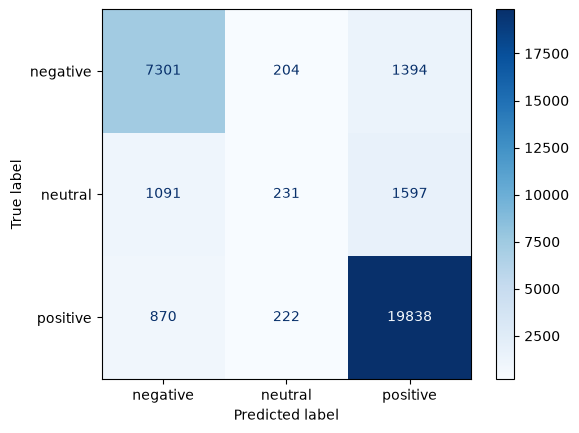

In [8]:
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(test_labels, predictions, labels=labels)
print(cm)

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', values_format='d')
plt.show()